# Term Deposit Subscription Prediction
**European Banking | Customer Intention Classification | Telemarketing Optimisation**

---

## Business Context

A European banking institution runs direct marketing campaigns via phone calls to
promote term deposit subscriptions. The current approach contacts customers
indiscriminately, resulting in low conversion rates, wasted agent resources, and
a poor customer experience.

**Goals:**
1. Predict whether a customer will subscribe to a term deposit (`y`)
2. Determine which features most strongly drive subscription decisions

**Success Metric:** 81%+ accuracy via 5-fold cross-validation (average score)
**Key Operational Metric:** Minority-class recall — catching actual subscribers

## Solution Design: Two-Layer Pipeline

Features fall into two groups separated by a temporal boundary:

| Layer | Features Available | Purpose |
|-------|--------------------|---------|
| **Model 1 : Pre-call** | Demographics + financial history | Predict who to call *before* any contact |
| **Model 2 : Post-call** | All features (incl. call data) | Predict who to *continue* calling after contact |

---
## Import Dependencies

In [22]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import duckdb

from config import SEED, DATA_FILE, CAMPAIGN_SIZE
from src.cluster_model import cluster_subscribers
from src.two_layer_model import (
    load_data, get_feature_sets, explore_data,
    split_data, data_cleaning, encode_data,
    select_model, compare_ensembles, tune_hyperparameters,
    feature_importance, evaluate_model
)

print(f"Seed: {SEED}")

ROOT = Path.cwd()
DATA_PATH = ROOT / DATA_FILE

Seed: 6000


---
## 1. Data Loading

In [23]:
term_deposit_df = load_data(DATA_PATH)
print(f"Shape: {term_deposit_df.shape[0]:,} rows x {term_deposit_df.shape[1]} columns")
term_deposit_df.head()

Shape: 40,000 rows x 14 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


---
## 2. Feature Groups

Features are split into pre-call and post-call groups based on when they become available.
`duration` is in the post-call group — it only exists after a call ends and must not
be used in Model 1 (data leakage).

In [24]:
pre_call_cols, post_call_cols = get_feature_sets(term_deposit_df)
all_cols = pre_call_cols + post_call_cols
print(f"Model 1 — Pre-call  : {pre_call_cols}")
print(f"Model 2 adds        : {post_call_cols}")

Model 1 — Pre-call  : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']
Model 2 adds        : ['contact', 'day', 'month', 'duration', 'campaign']


---
## 3. Exploratory Data Analysis

EDA covers target distribution, feature distributions by class, numeric histograms,
correlation structure, and identification of structural missing values (`"unknown"`).

       age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
39995   53    technician   married   tertiary      no      395      no   no   
39996   30    management    single   tertiary      no     3340      no   no   
39997   54         admin  divorced  secondary      no      200      no   no   
39998   34    management   married   tertiary      no     1047      no   no   
39999   38    technician   married  secondary      no     1442     yes   no   

        contact  day month  duration  campaign    y  
0       unknown    5   may       261         1   no  
1       unknown    5  

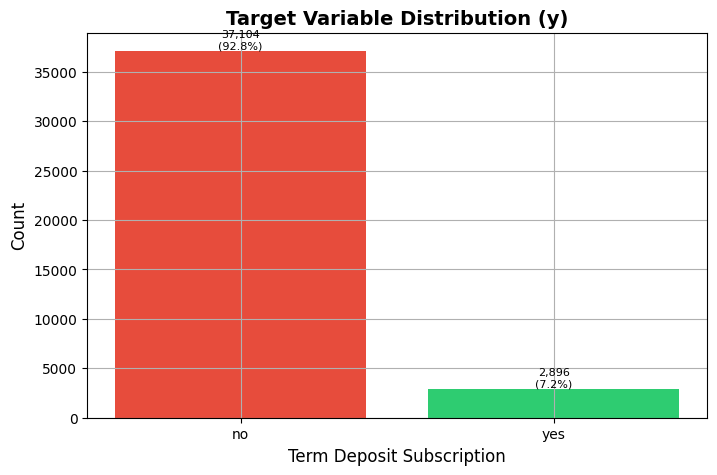


--- job ---
job
blue-collar      9383
management       8166
technician       6852
admin            4483
services         3910
retired          1437
self-employed    1414
entrepreneur     1405
unemployed       1104
housemaid        1087
student           524
unknown           235
Name: count, dtype: int64


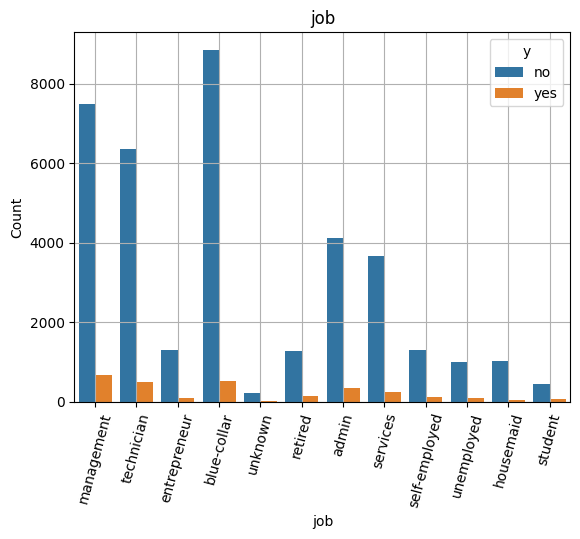


--- marital ---
marital
married     24386
single      10889
divorced     4725
Name: count, dtype: int64


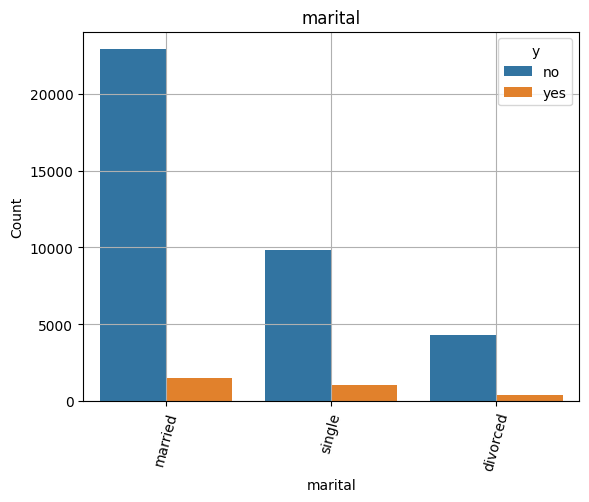


--- education ---
education
secondary    20993
tertiary     11206
primary       6270
unknown       1531
Name: count, dtype: int64


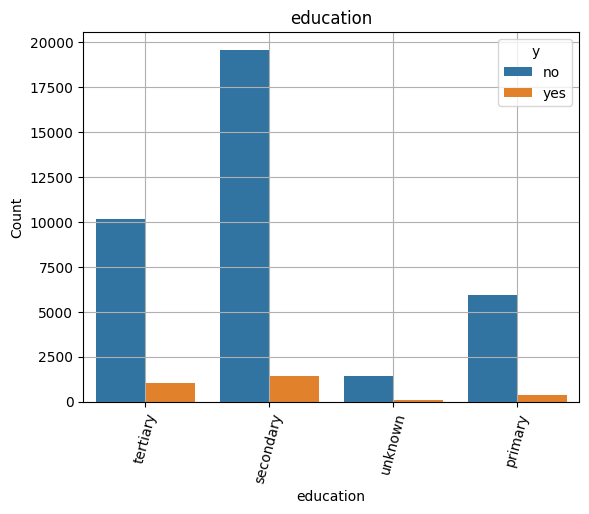


--- default ---
default
no     39191
yes      809
Name: count, dtype: int64


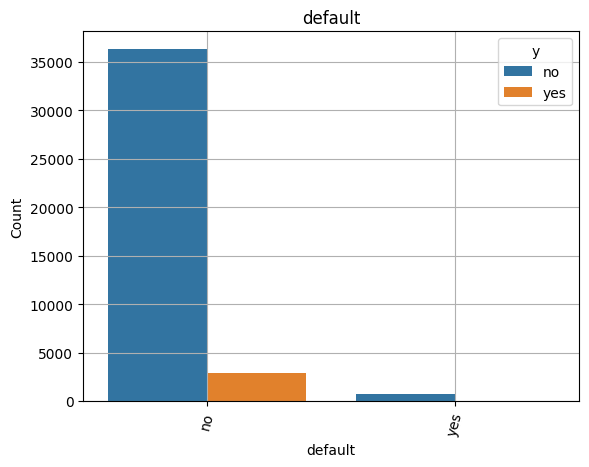


--- housing ---
housing
yes    24031
no     15969
Name: count, dtype: int64


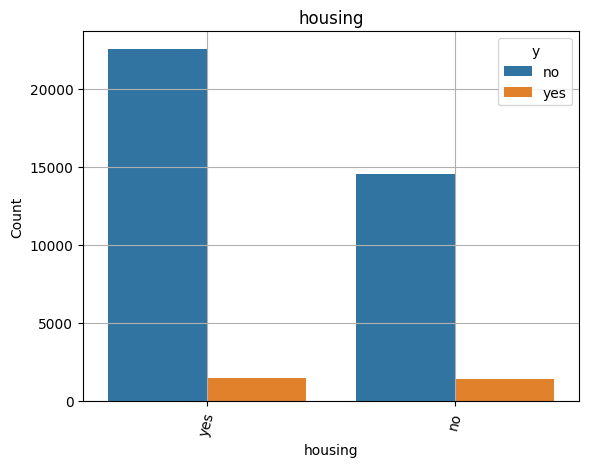


--- loan ---
loan
no     33070
yes     6930
Name: count, dtype: int64


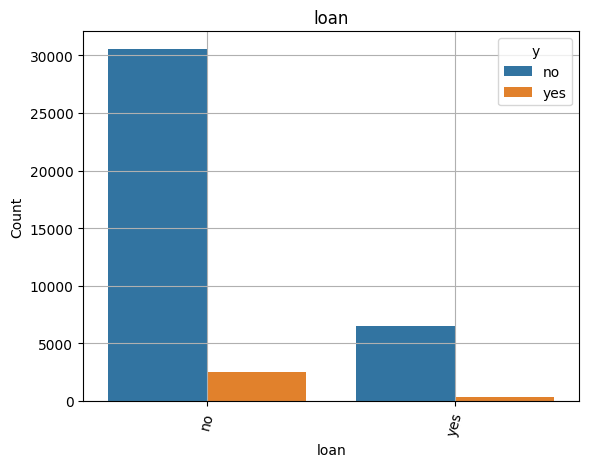


--- contact ---
contact
cellular     24914
unknown      12765
telephone     2321
Name: count, dtype: int64


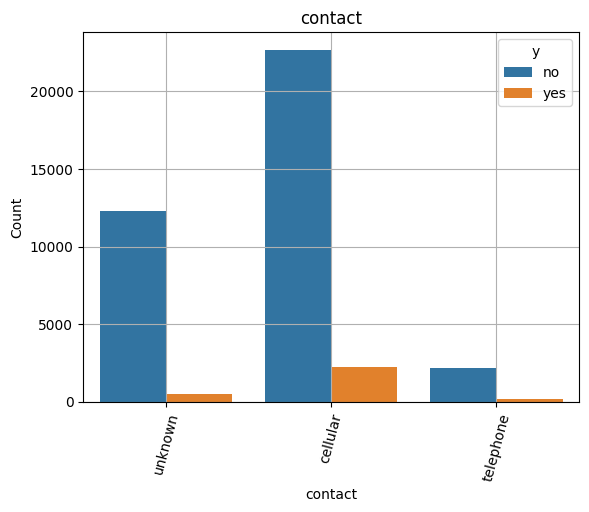


--- month ---
month
may    13532
jul     6380
aug     5215
jun     4734
nov     3598
apr     2718
feb     2296
jan     1176
mar      258
oct       80
dec       13
Name: count, dtype: int64


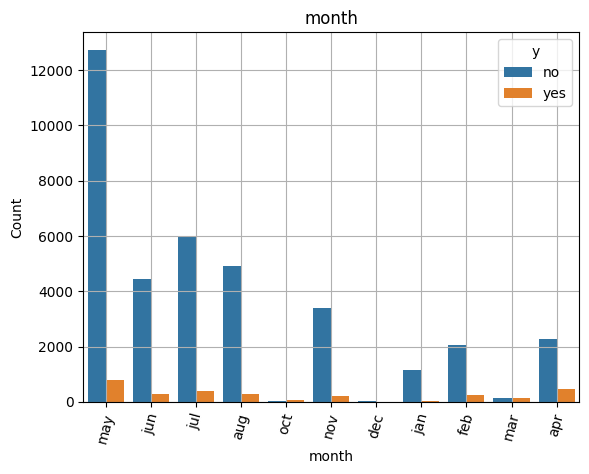


Unknown value counts:
  job: 235 (0.6%)
  education: 1,531 (3.8%)
  contact: 12,765 (31.9%)

Pairwise overlap:
  job & education: 104
  job & contact: 110
  education & contact: 666
  all three: 54

Rows lost if any unknown dropped: 13,705 (34.3%)


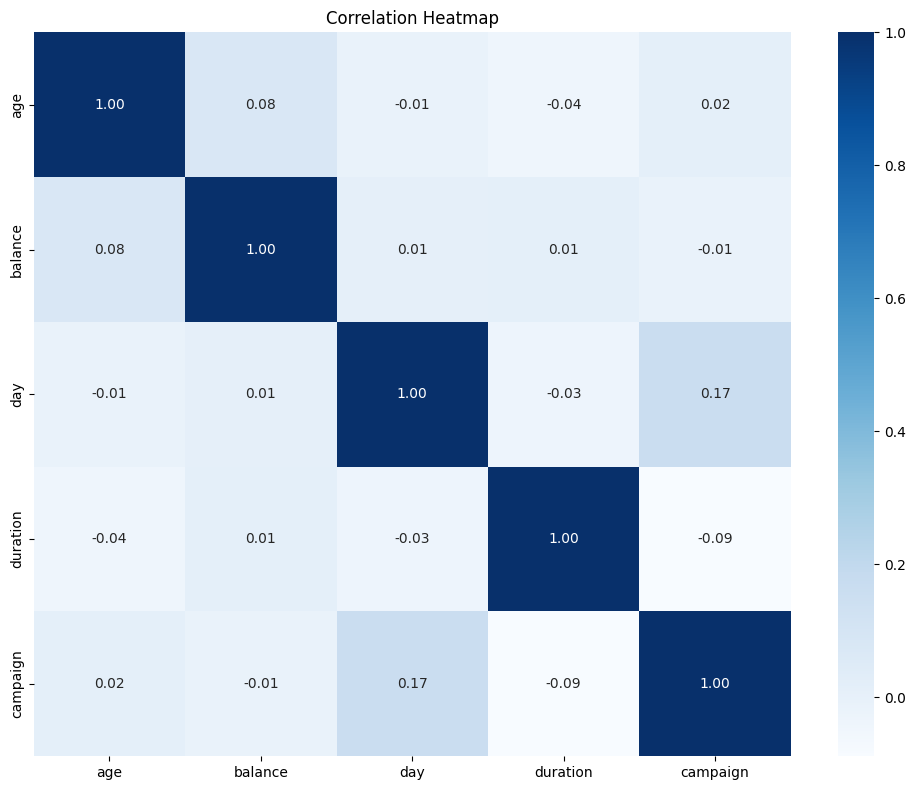

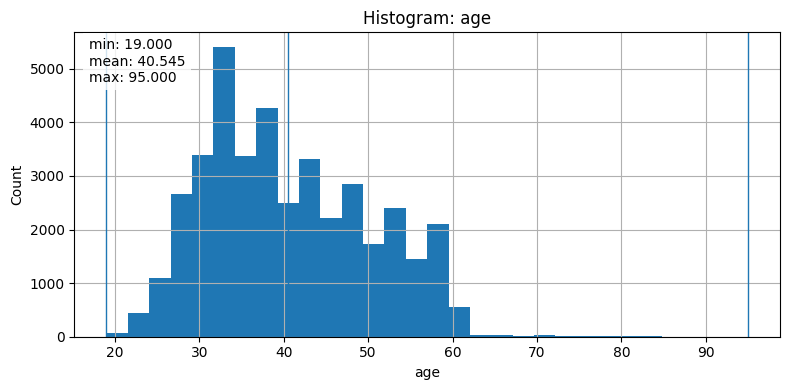

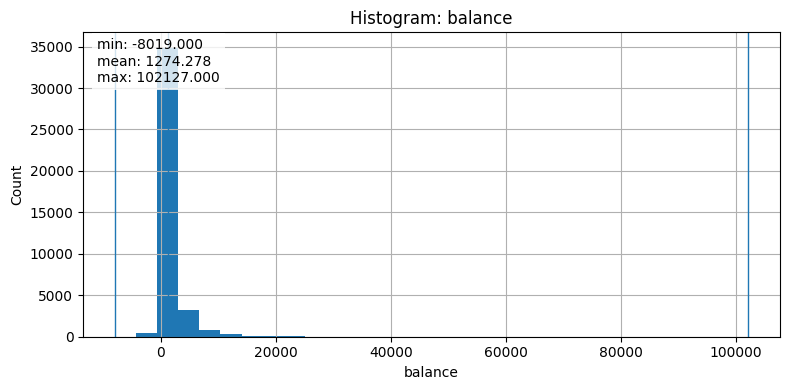

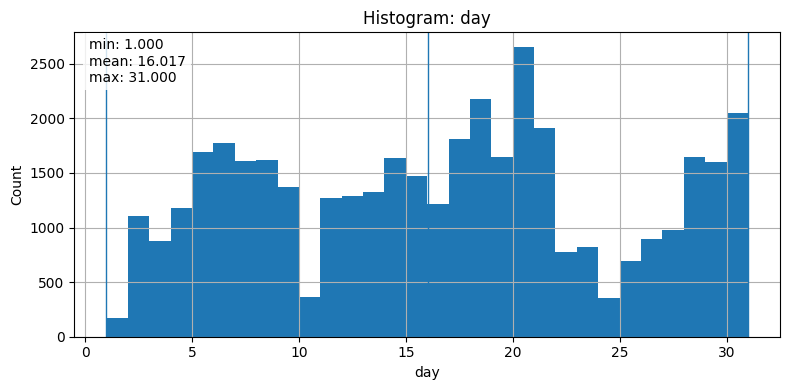

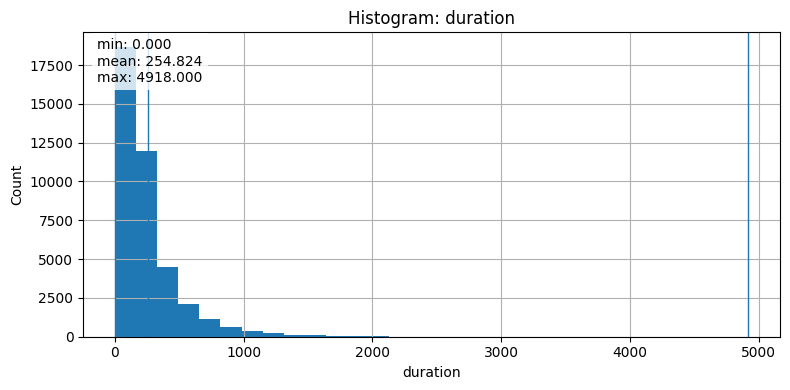

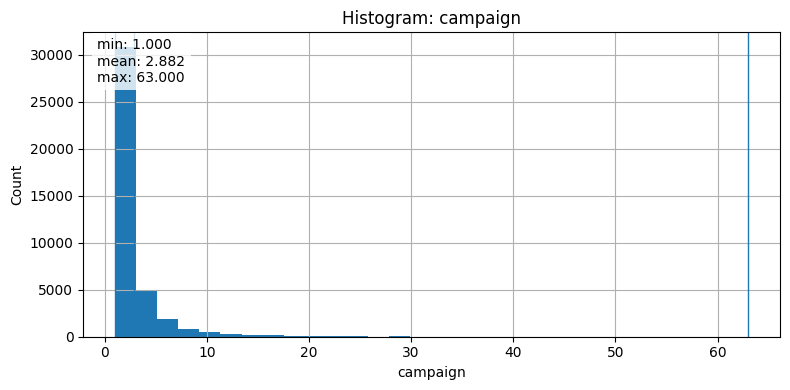

campaign: min=1, max=63 (# contacts this campaign)


In [25]:
numeric_df, categorical_df = explore_data(term_deposit_df)

### Key Findings

#### Class Imbalance

| Class | Count | Share |
|-------|-------|-------|
| No (did not subscribe) | 37104 | 92.8% |
| Yes (subscribed) | 2896 | 7.2% |

The dataset is highly imbalanced. A majority-class classifier achieves 93% accuracy
while being useless to the business. This drives two decisions:
- **Metric:** Optimise for minority-class recall alongside the 81% accuracy target
- **Model config:** `class_weight='balanced'` to penalise missed subscribers

---

#### Numeric Variables

- **`age`:** Range 18–95, mean ~41. No anomalies.
- **`balance`:** Average yearly balance in euros. Can be negative (overdrafts).
  Range −8,019 to 102,127; highly right-skewed with significant outliers.
- **`day`:** Day of month of last contact (1–31). Not a duration. Most calls have been made around 20th
- **`duration`:** Last call duration in seconds. Highly predictive but only known
  *after* the call ends; excluded from Model 1 to prevent data leakage.
- **`campaign`:** Number of contacts made this campaign. Most customers are contacted
  1–3 times; the distribution has a heavy right tail. Maximum value is 63 which seems an outlier.

---

#### Categorical Variables

- **`job`:** Management, blue-collar, and technician are the three most common categories.
- **`marital`:** Married customers are the majority.
- **`education`:** Secondary education is the most frequent level.
- **`default`:** Very few customers have credit in default — a rare event in the dataset.
- **`housing`:** Roughly evenly split between customers with and without a housing loan.
- **`loan`:** Most customers do not hold a personal loan.
- **`contact`:** The majority of contacts were made via cellular. A substantial portion
  of records have an unknown contact type (see table below).
- **`month`:** May has the highest contact volume by a large margin. No calls were made
  in September, suggesting campaign scheduling constraints.

---

#### Structural Missing Values ("unknown")

Pandas reports zero nulls but it is assumed that the missingness is encoded as the string `"unknown"`:

| Column | Count | % of Dataset |
|--------|-------|-------------|
| `contact` | 12,765 | 31.9% |
| `education` | 1,531 | 3.8% |
| `job` | 235 | 0.6% |

**Overlap analysis** — rows where multiple columns are unknown simultaneously:

| Pair | Rows |
|------|------|
| `contact` & `education` | 666 |
| `contact` & `job` | 110 |
| `education` & `job` | 104 |
| All three | 54 |
| Any one (union) | 13,705 (34.3%) |

**Why rows were not dropped:**
Dropping any row containing "unknown" would remove 34.3% of the dataset, nearly all of it
driven by `contact` alone. Given the existing class imbalance, discarding that volume
would significantly reduce minority-class representation in training.

**Design decision — hybrid imputation strategy:**
- **`contact`** → "unknown" retained as a valid category. At 31.9%, this is not random
  missingness but a distinct cohort (customers reached via an unlogged channel). LabelEncoder assigns
  it its own integer; LightGBM can learn from it.
- **`education` and `job`** → mode-imputed. Sparse unknowns (3.8% and 0.6%) with no
  evidence they form a meaningful segment. Mode imputation is simple and introduces
  negligible bias at this volume.

---

#### Outliers

IQR-based clipping `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]` is applied to all numeric features.
Bounds are computed on training data only to prevent leakage.

---
## 4. Preprocessing Pipeline

All transformations are **fitted on training data only**; no leakage at any stage.

| Step | Method | Rationale |
|------|--------|-----------|
| Train / Val / Test split | Stratified 80 / 10 / 10 | Preserves the 93/7 class ratio across all sets |
| `contact` "unknown" | Kept as valid category | 31.9% — informative cohort, not random missingness |
| `education`, `job` "unknown" | Mode imputation | Sparse unknowns; mode fitted on train only |
| Outlier handling | IQR clipping | Reduces outlier influence without removing rows |
| Categorical encoding | `LabelEncoder` | Converts string categories to integers; compatible with all sklearn estimators |
| Numeric scaling | `StandardScaler` | Features span mixed distributions (`balance`, `duration`, `campaign` are skewed; `age` near-normal; `day` uniform). After IQR clipping, extreme outliers are removed; StandardScaler centres and scales each feature to zero mean and unit variance without distortion |
| Target encoding | `LabelEncoder` | `no` → 0, `yes` → 1 |

### Step 4.1 — Train / Validation / Test Split

In [26]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    term_deposit_df, target="y", seed=SEED
)

Train: 32000 | Val: 4000 | Test: 4000


### Step 4.2 — Data Cleaning

Outlier clipping (IQR) fitted on train, applied to val.
Mode imputation for `education` and `job` only; `contact` "unknown" kept as-is.

In [27]:
X_train_cleaned, X_val_cleaned, cat_mode, num_bounds, cat_cols, num_cols = data_cleaning(
    X_train, X_val, categorical_df, numeric_df
)
print("Mode values used for imputation:", cat_mode)

{'job': 'blue-collar', 'marital': 'married', 'education': 'secondary', 'default': 'no', 'housing': 'yes', 'loan': 'no', 'month': 'may'} {'age': (np.float64(10.5), np.float64(70.5)), 'balance': (np.float64(-1830.0), np.float64(3194.0)), 'day': (np.float64(-11.5), np.float64(40.5)), 'duration': (np.float64(-217.5), np.float64(626.5)), 'campaign': (np.float64(-2.0), np.float64(6.0))}
Mode values used for imputation: {'job': 'blue-collar', 'marital': 'married', 'education': 'secondary', 'default': 'no', 'housing': 'yes', 'loan': 'no', 'month': 'may'}


---
## 5. Model Selection

**LazyPredict** benchmarks 30+ classifiers in a single pass, ranked by minority-class
recall on the validation set.

**Selected: LightGBM (`LGBMClassifier`)**

| Criterion | LightGBM |
|-----------|----------|
| Minority-class recall | Consistently top-ranked |
| Class imbalance | Native `class_weight='balanced'` support |
| Interpretability | Feature importance for client-facing insights |
| Speed | Practical for repeated tuning and production retraining |

---
## 6. Hyperparameter Tuning

**Hyperopt** with TPE (Tree-structured Parzen Estimator) performs Bayesian optimisation.
Objective: maximise average minority-class recall across 5-fold cross-validation.

| Parameter | Range | Purpose |
|-----------|-------|---------|
| `n_estimators` | 50–500 | Boosting iterations |
| `max_depth` | 2–8 | Tree depth, controls overfitting |
| `learning_rate` | 0.05–0.2 | Step size shrinkage |
| `num_leaves` | 5–31 | Tree complexity |
| `min_child_samples` | 10–30 | Leaf regularisation |
| `subsample` | 0.7–0.9 | Row sampling |
| `colsample_bytree` | 0.7–0.9 | Feature sampling |

TPE converges in ~50 evaluations by learning from prior trials, where grid search
across this space would require ~1,000+.

---
## 7. Model 1 — Pre-Call Targeting
*Feature set: demographics + financial history only (no call data)*

### Step 7.1 — Encode Features (Model 1)

In [28]:
pre_cat_cols = [c for c in pre_call_cols if c in cat_cols]
pre_num_cols = [c for c in pre_call_cols if c in num_cols]

X_tr_m1, X_va_m1, y_tr_enc, y_va_enc, le1, sc1, le_y1 = encode_data(
    X_train_cleaned[pre_call_cols], X_val_cleaned[pre_call_cols],
    y_train, y_val, pre_cat_cols, pre_num_cols
)
print(f"Model 1 training shape : {X_tr_m1.shape}")
print(f"Features               : {X_tr_m1.columns.tolist()}")

Model 1 training shape : (32000, 8)
Features               : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']


### Step 7.2 — Model Selection (Model 1)

In [29]:
models_df1, _ = select_model(X_tr_m1, X_va_m1, y_tr_enc, y_va_enc)
print(models_df1)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2317, number of negative: 29683
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000759 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 338
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.072406 -> initscore=-2.550301
[LightGBM] [Info] Start training from score -2.550301

Best model for minority recall: NearestCentroid
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
NearestCentroid                    0.58               0.57     0.57      0.68   
DecisionTreeClassifier             0.87               0.54     0.54      0.87   
BaggingClassifier                  0.92               0.53     0.53     

### Step 7.3 — Ensemble Comparison (Model 1)

Compares tree-based, distance-based, and ensemble strategies via 5-fold CV minority recall.
The best-performing architecture is then carried forward to hyperparameter tuning.

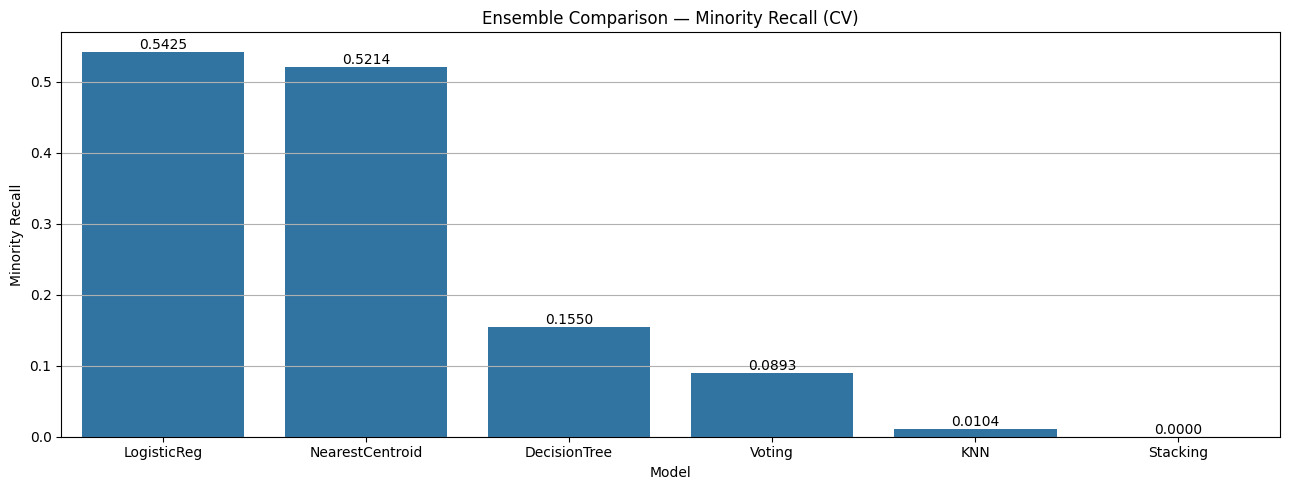

             Model  Minority_Recall
0      LogisticReg             0.54
1  NearestCentroid             0.52
2     DecisionTree             0.15
3           Voting             0.09
4              KNN             0.01
5         Stacking             0.00


In [30]:
fitted_models1, ensemble_df1 = compare_ensembles(X_tr_m1, y_tr_enc, SEED)
print(ensemble_df1)

### Step 7.4 — Hyperparameter Tuning (Model 1)

In [31]:
model1, params1, score1 = tune_hyperparameters(X_tr_m1, y_tr_enc, X_va_m1, y_va_enc, SEED)

100%|██████████| 10/10 [04:01<00:00, 24.14s/trial, best loss: -0.5500489038909848]
Best Params: {'C': 69.03471531603735, 'penalty': 'l1'}
Best Minority Recall (CV): 0.5500


### Step 7.5 — Feature Importance (Model 1)

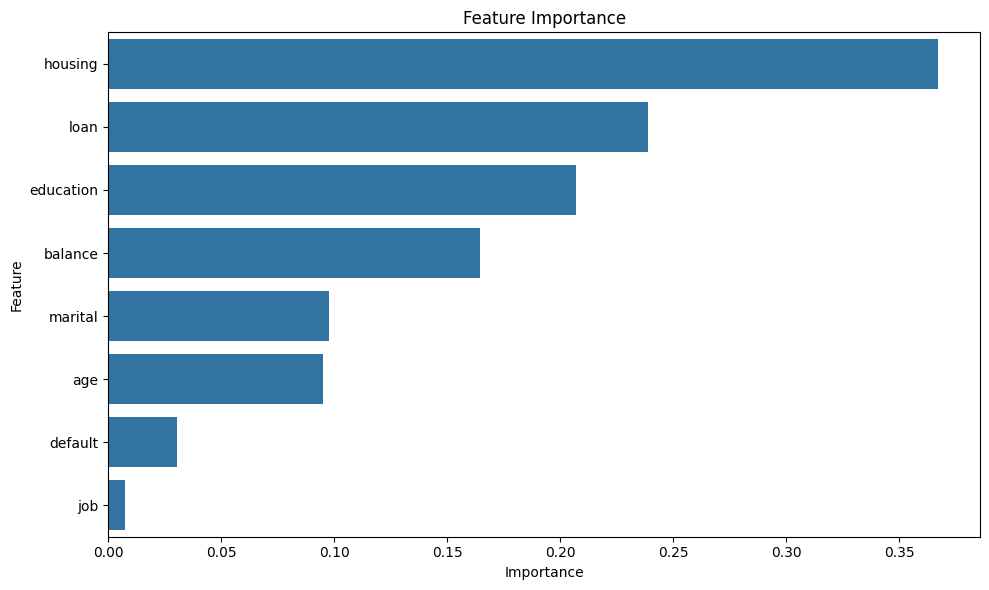

     Feature  Importance
0    housing        0.37
1       loan        0.24
2  education        0.21
3    balance        0.16
4    marital        0.10
5        age        0.09
6    default        0.03
7        job        0.01


In [32]:
feat1 = feature_importance(X_tr_m1, model1)
print(feat1)

### Step 7.6 — Evaluation on Test Set (Model 1)

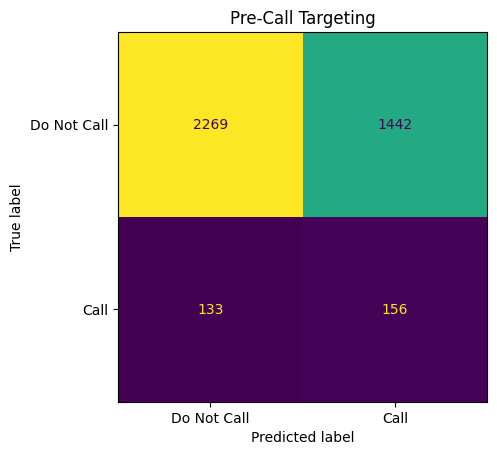

              precision    recall  f1-score   support

          no       0.94      0.61      0.74      3711
         yes       0.10      0.54      0.17       289

    accuracy                           0.61      4000
   macro avg       0.52      0.58      0.45      4000
weighted avg       0.88      0.61      0.70      4000



In [33]:
report1, cm1 = evaluate_model(
    model1, X_test[pre_call_cols].copy(), y_test,
    le1, sc1, le_y1,
    pre_cat_cols, pre_num_cols, cat_mode, num_bounds, pre_call_cols, "Model1"
)
print(report1)

---
## 8. Model 2 — Post-Call Follow-Up
*Feature set: all features including call data (`duration`, `contact`, `month`, `day`, `campaign`)*

### Step 8.1 — Encode Features (Model 2)

In [34]:
all_cat_cols = [c for c in all_cols if c in cat_cols]
all_num_cols = [c for c in all_cols if c in num_cols]

X_tr_m2, X_va_m2, y_tr_enc2, y_va_enc2, le2, sc2, le_y2 = encode_data(
    X_train_cleaned[all_cols], X_val_cleaned[all_cols],
    y_train, y_val, all_cat_cols, all_num_cols
)
print(f"Model 2 training shape : {X_tr_m2.shape}")
print(f"Features               : {X_tr_m2.columns.tolist()}")

Model 2 training shape : (32000, 13)
Features               : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign']


### Step 8.2 — Model Selection (Model 2)

In [35]:
models_df2, _ = select_model(X_tr_m2, X_va_m2, y_tr_enc2, y_va_enc2)
print(models_df2)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2317, number of negative: 29683
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000841 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 648
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.072406 -> initscore=-2.550301
[LightGBM] [Info] Start training from score -2.550301

Best model for minority recall: NearestCentroid
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
NearestCentroid                    0.82               0.81     0.81      0.86   
LinearDiscriminantAnalysis         0.92               0.72     0.72      0.92   
QuadraticDiscriminantAnalysis      0.92               0.71     0.71    

### Step 8.3 — Ensemble Comparison (Model 2)

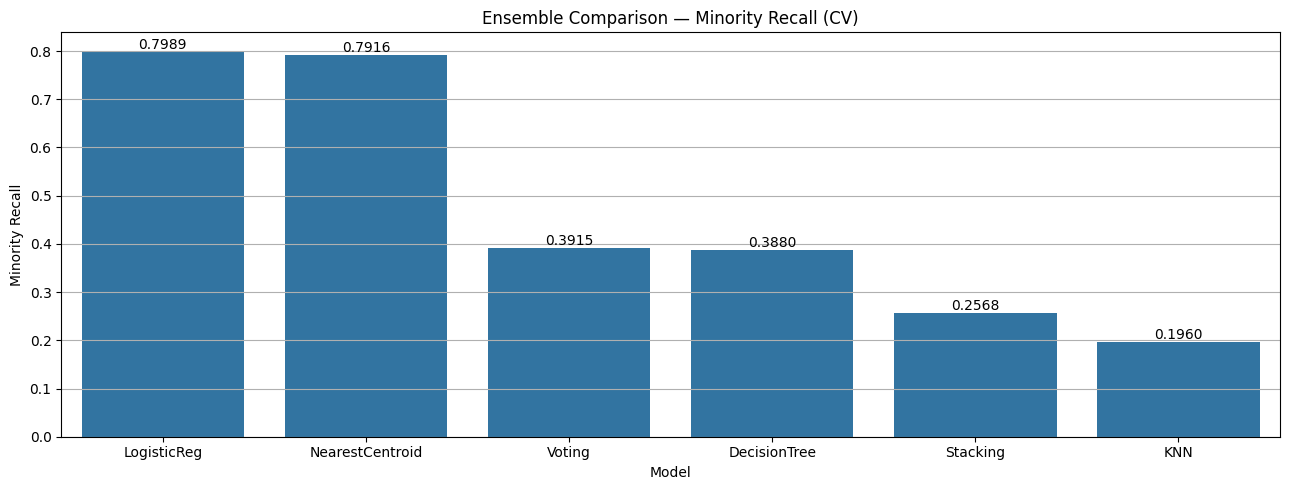

             Model  Minority_Recall
0      LogisticReg             0.80
1  NearestCentroid             0.79
2           Voting             0.39
3     DecisionTree             0.39
4         Stacking             0.26
5              KNN             0.20


In [36]:
fitted_models2, ensemble_df2 = compare_ensembles(X_tr_m2, y_tr_enc2, SEED)
print(ensemble_df2)

### Step 8.4 — Hyperparameter Tuning (Model 2)

In [37]:
model2, params2, score2 = tune_hyperparameters(X_tr_m2, y_tr_enc2, X_va_m2, y_va_enc2, SEED)

100%|██████████| 10/10 [00:06<00:00,  1.49trial/s, best loss: -0.8032173612489981]
Best Params: {'C': 3.8967693092281617, 'penalty': 'l2'}
Best Minority Recall (CV): 0.8032


### Step 8.5 — Feature Importance (Model 2)

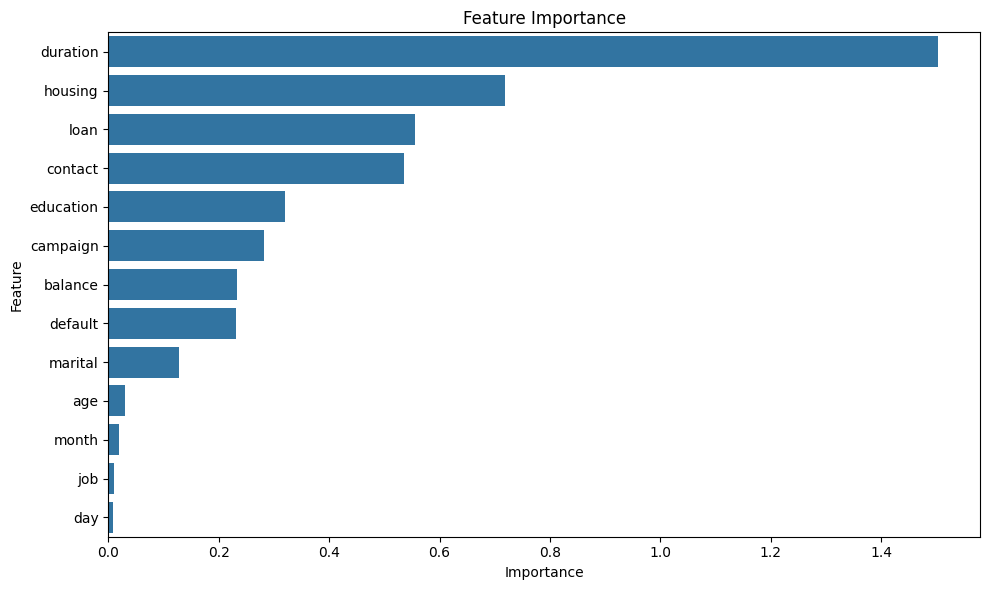

      Feature  Importance
0    duration        1.50
1     housing        0.72
2        loan        0.56
3     contact        0.54
4   education        0.32
5    campaign        0.28
6     balance        0.23
7     default        0.23
8     marital        0.13
9         age        0.03
10      month        0.02
11        job        0.01
12        day        0.01


In [38]:
feat2 = feature_importance(X_tr_m2, model2)
print(feat2)

### Step 8.6 — Evaluation on Test Set (Model 2)

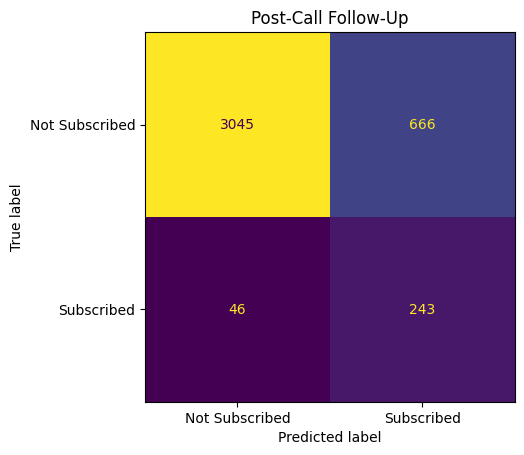

              precision    recall  f1-score   support

          no       0.99      0.82      0.90      3711
         yes       0.27      0.84      0.41       289

    accuracy                           0.82      4000
   macro avg       0.63      0.83      0.65      4000
weighted avg       0.93      0.82      0.86      4000



In [39]:
report2, cm2 = evaluate_model(
    model2, X_test[all_cols].copy(), y_test,
    le2, sc2, le_y2,
    all_cat_cols, all_num_cols, cat_mode, num_bounds, all_cols, "Model2"
)
print(report2)

---
## 9. Results Summary

In [40]:
print("Model 1: Who to Call (Pre-Call Targeting)")
print("  Business question : Which customers are worth contacting?")
print(f"  CV Minority Recall : {score1:.4f}")
print("  Feature Importance:")
print(feat1.to_string(index=False))

print("\nModel 2: Who Will Subscribe (Post-Call Follow-Up)")
print("  Business question : Of those contacted, who is likely to subscribe?")
print(f"  CV Minority Recall : {score2:.4f}")
print("  Feature Importance:")
print(feat2.to_string(index=False))

Model 1: Who to Call (Pre-Call Targeting)
  Business question : Which customers are worth contacting?
  CV Minority Recall : 0.5500
  Feature Importance:
  Feature  Importance
  housing        0.37
     loan        0.24
education        0.21
  balance        0.16
  marital        0.10
      age        0.09
  default        0.03
      job        0.01

Model 2: Who Will Subscribe (Post-Call Follow-Up)
  Business question : Of those contacted, who is likely to subscribe?
  CV Minority Recall : 0.8032
  Feature Importance:
  Feature  Importance
 duration        1.50
  housing        0.72
     loan        0.56
  contact        0.54
education        0.32
 campaign        0.28
  balance        0.23
  default        0.23
  marital        0.13
      age        0.03
    month        0.02
      job        0.01
      day        0.01


### Business Impact

In [41]:
tn1, fp1, fn1, tp1 = cm1.ravel()
total1 = tn1 + fp1 + fn1 + tp1

predicted_no_call   = tn1 + fn1
predicted_call      = tp1 + fp1
pct_saved           = predicted_no_call / total1

calls_saved         = int(pct_saved * CAMPAIGN_SIZE)
useless_calls_test  = fp1
missed_subs_test    = fn1
correct_calls_test  = tp1

avg_duration_sec     = X_train['duration'].mean()
avg_duration_min     = avg_duration_sec / 60
hours_saved_test     = predicted_no_call * avg_duration_sec / 3600
hours_saved_campaign = calls_saved * avg_duration_sec / 3600

print(f"Business Impact: Model 1 (Pre-Call Targeting)")
print(f"  Test set size               : {total1:,}")
print(f"  Predicted 'Do Not Call'     : {predicted_no_call:,}  ({100 * pct_saved:.1f}% of test set)")
print(f"  Predicted 'Call'            : {predicted_call:,}")
print()
print(f"  Scaled to {CAMPAIGN_SIZE:,} campaign contacts:")
print(f"    Calls avoided (saved manpower) by the company is : {calls_saved:,}")
print()
print(f"  Average call duration       : {avg_duration_sec:.0f}s  ({avg_duration_min:.1f} min)")
print(f"  Hours saved (test)    : {hours_saved_test:.1f} hours")
print(f"  Hours saved ({CAMPAIGN_SIZE:,})  : {hours_saved_campaign:.0f} hours  ({hours_saved_campaign/8:.0f} working days)")
print()
print(f"  Within the {predicted_call:,} calls made (test set):")
print(f"    Correctly targeted        : {correct_calls_test:,}  (likely subscribers)")
print(f"    Useless calls             : {useless_calls_test:,}  (won't subscribe)")
print(f"    Missed subscribers        : {missed_subs_test:,}  (false negatives)")

Business Impact: Model 1 (Pre-Call Targeting)
  Test set size               : 4,000
  Predicted 'Do Not Call'     : 2,402  (60.1% of test set)
  Predicted 'Call'            : 1,598

  Scaled to 40,000 campaign contacts:
    Calls avoided (saved manpower) by the company is : 24,020

  Average call duration       : 254s  (4.2 min)
  Hours saved (test)    : 169.3 hours
  Hours saved (40,000)  : 1693 hours  (212 working days)

  Within the 1,598 calls made (test set):
    Correctly targeted        : 156  (likely subscribers)
    Useless calls             : 1,442  (won't subscribe)
    Missed subscribers        : 133  (false negatives)


---
## 10. Subscriber Segmentation — KMeans Clustering

### Encoding — One-Hot Encoding
One-Hot Encoding is used for categorical features to avoid implying a false ordinal
relationship between categories.

### Feature Selection — All Features
All available features are included because the full feature space gives the most complete
subscriber profile.

### Correlation — Numerical Features Only
Spearman correlation is used on numerical features only — Pearson is not defined
for categorical variables, and Spearman is more robust to the skewed distributions
of `balance`, `duration`, and `campaign`.

**Insight 1:** `duration` and `campaign` have a positive correlation,
meaning subscribers who required more contact attempts also tended to have
longer calls — persistent outreach is associated with more engaged conversations.

**Insight 2:** `age` and `balance` show a higher correlation among subscribers,
indicating that older subscribers tend to hold greater account balances —
a useful demographic signal for targeting.

### Elbow Method
The Elbow method plots WCSS (total within-cluster variance) against k; the
optimal k is the point where adding more clusters does not reduce the score much.
The annotation is placed at the k where the second difference of WCSS drops
is maximum — i.e. where the curve bends most sharply. `best_k` is automatically
set to this elbow value.

### Silhouette Score
Silhouette score measures how similar each point is to its own cluster versus
neighbouring clusters (range −1 to 1); it provides a second, independent
confirmation of the optimal k beyond the elbow method.

### Dimensionality Reduction
PCA, t-SNE, and UMAP compress all features into 2 or 3 components; KMeans
then clusters subscribers in that reduced space.

### Cluster Plots
The 2×3 grid shows `best_k` clusters (set dynamically by the elbow method),
comparing 2-component (2D) versus 3-component (3D) reductions side by side.


Subscribers: 2,896


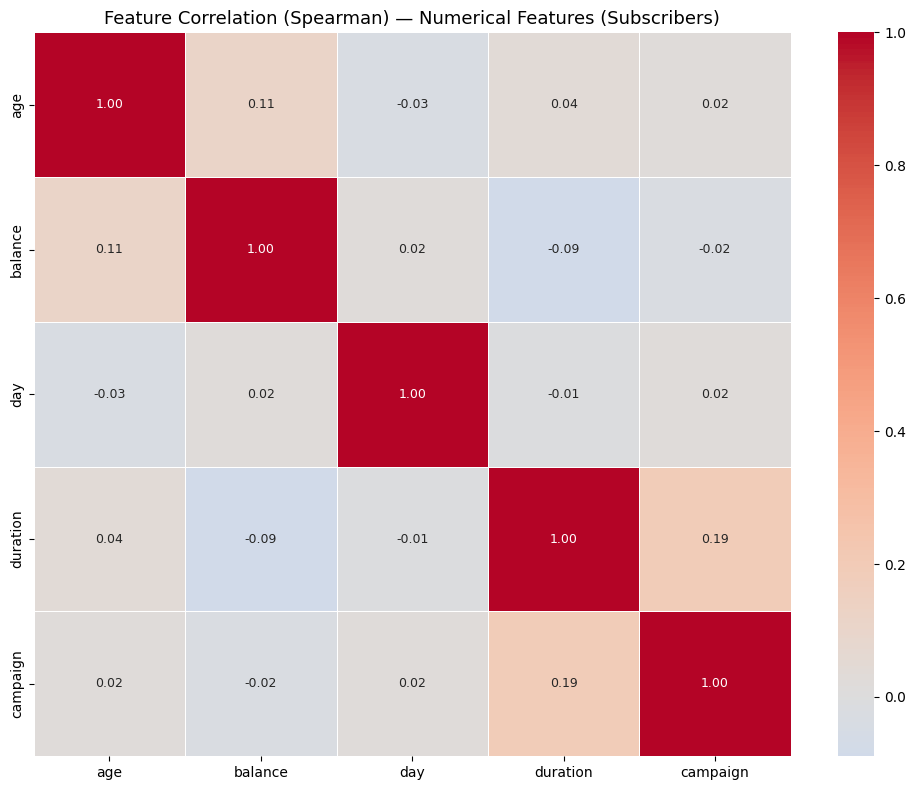

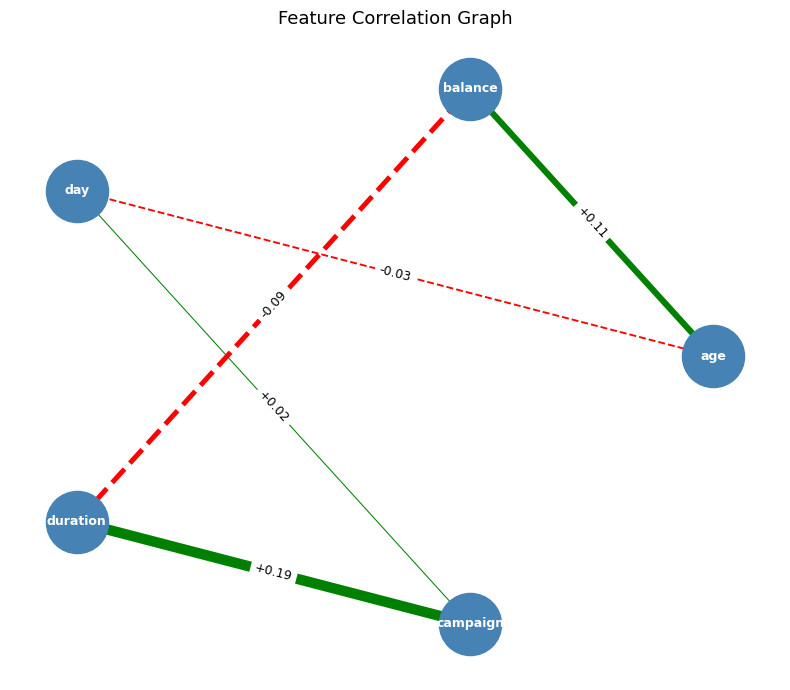

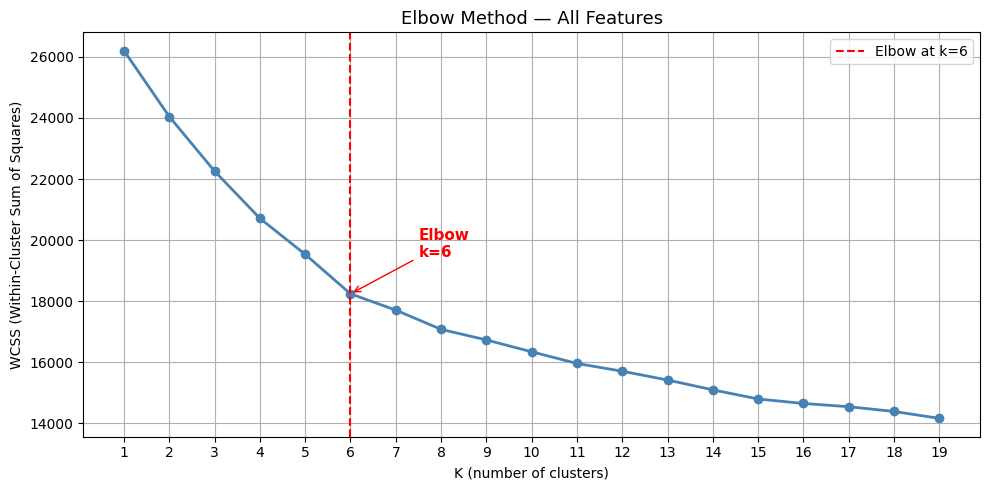

Elbow detected at k=6 | Using best_k=6


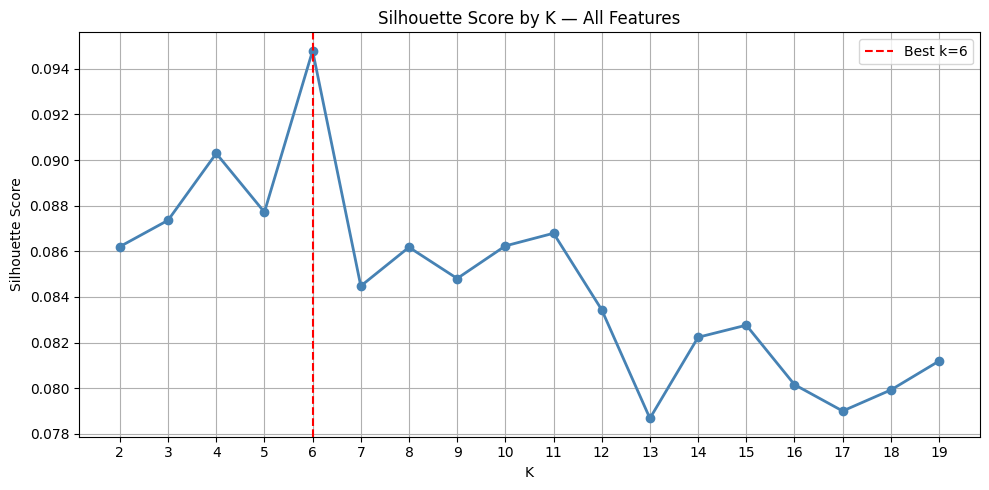

Highest silhouette score at k=6 | Using best_k=6 (elbow)


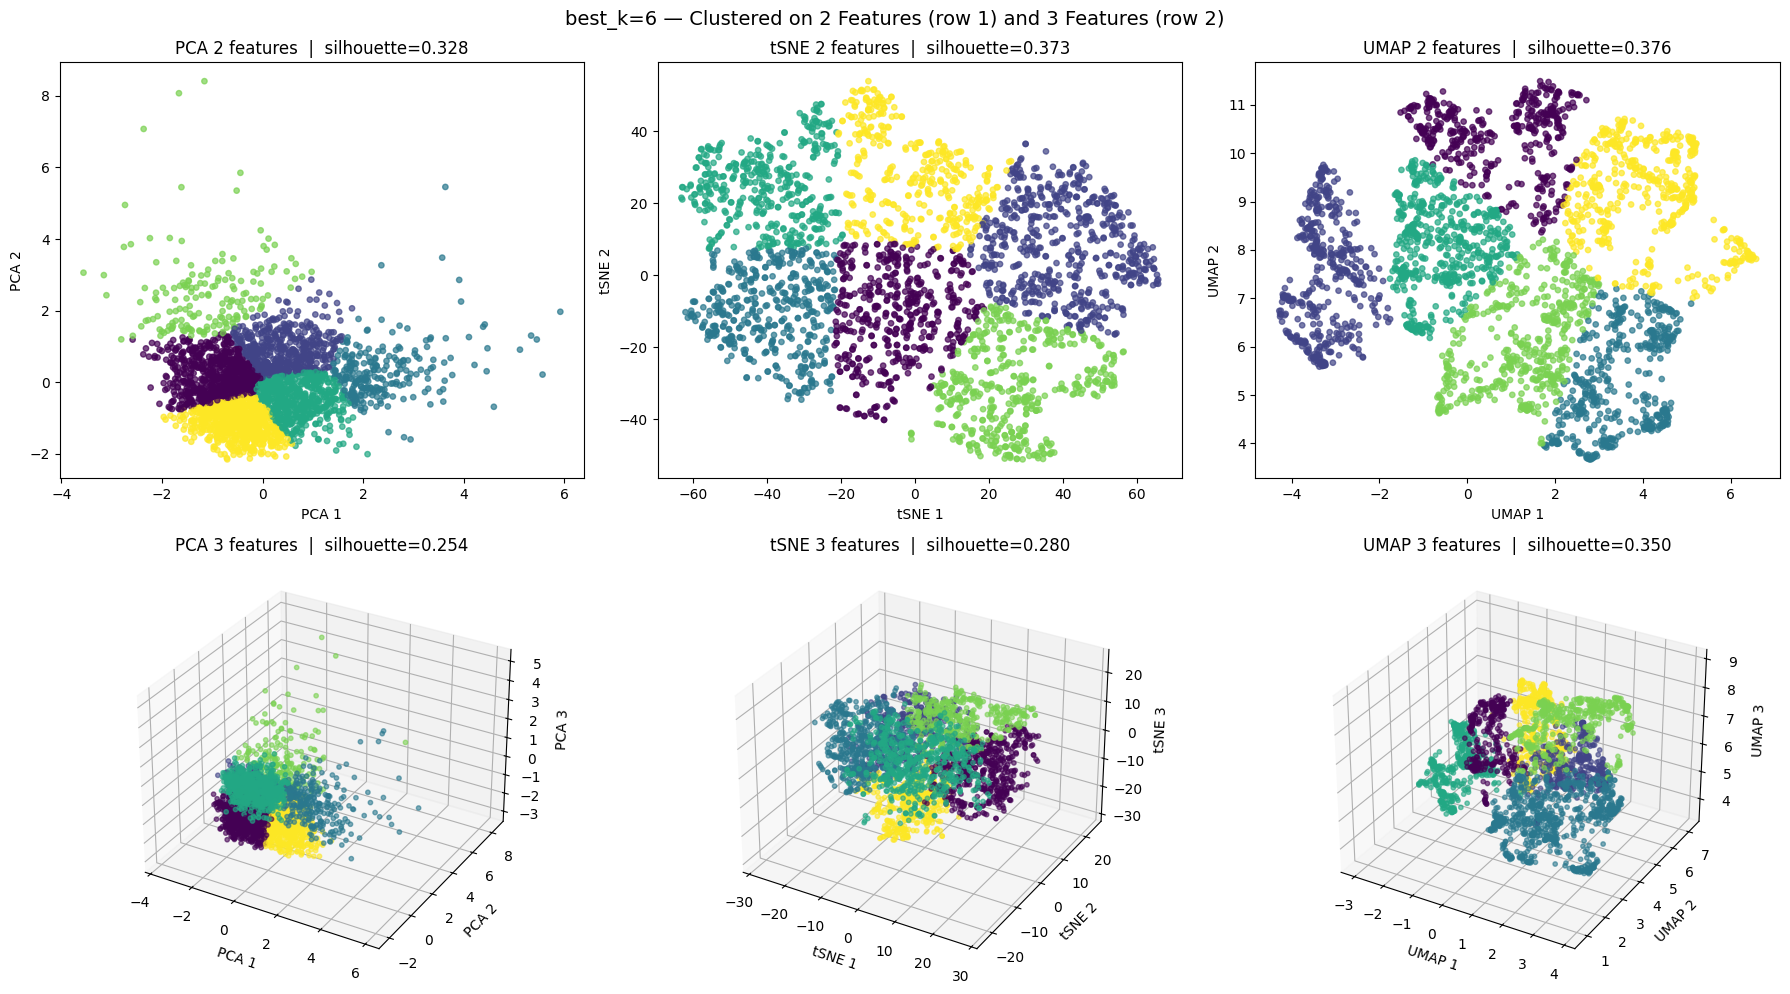

Profile cluster label counts: {0: 779, 1: 561, 2: 100, 3: 159, 4: 599, 5: 698}


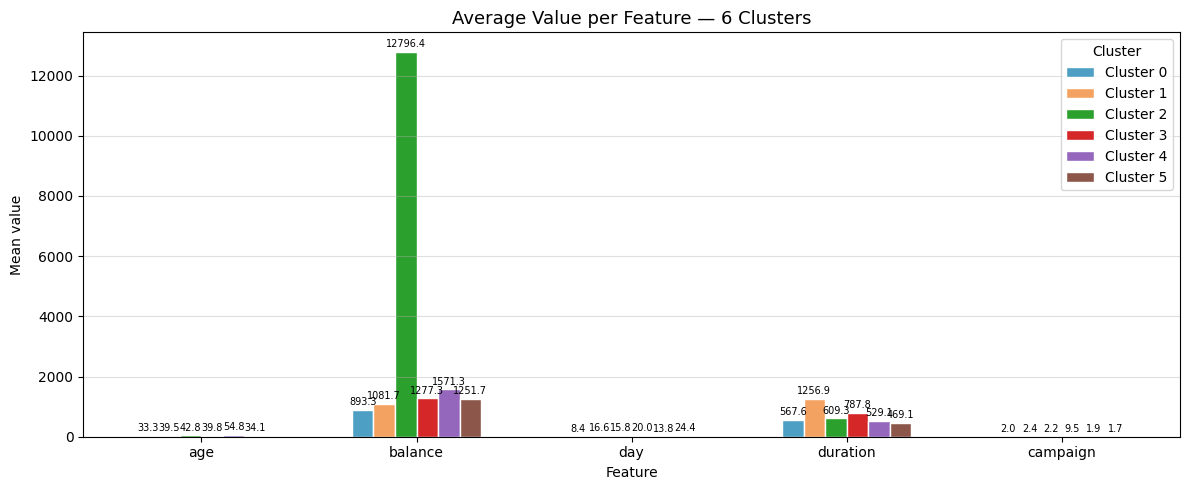

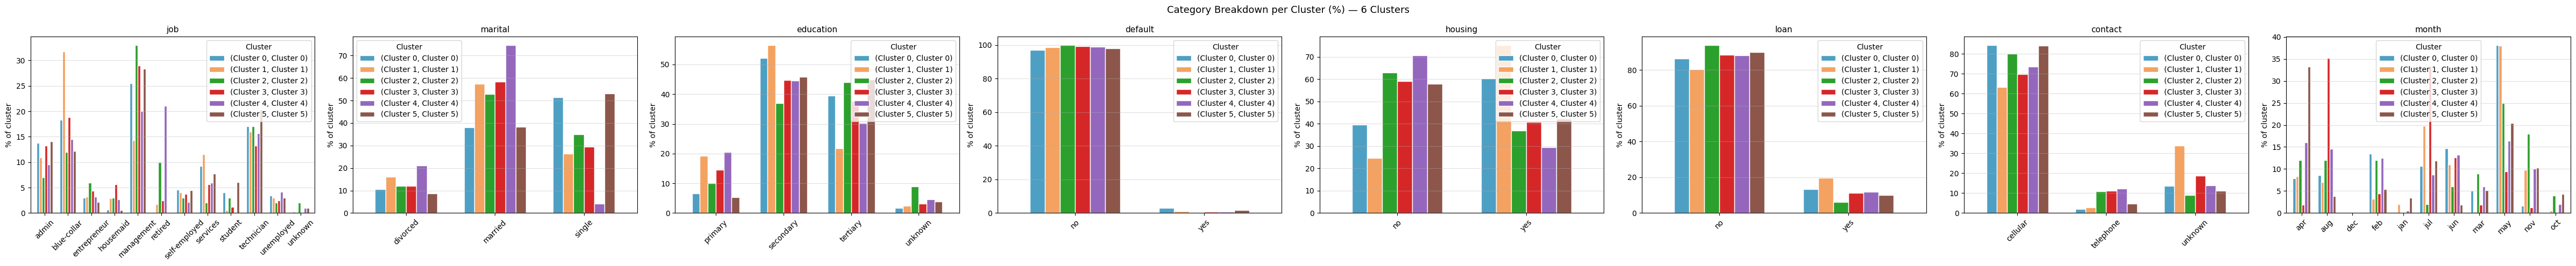

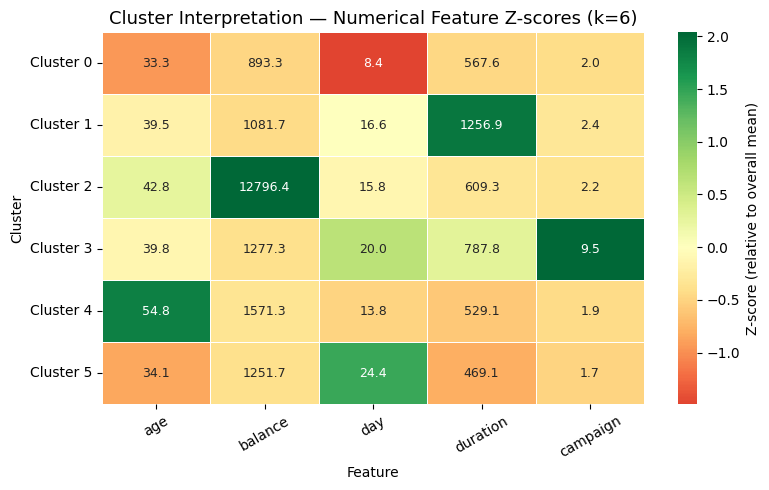

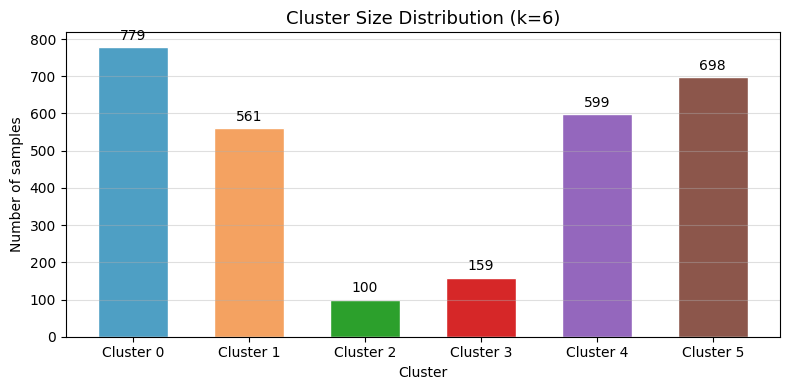


 Cluster sizes
cluster
Cluster 0    779
Cluster 5    698
Cluster 4    599
Cluster 1    561
Cluster 3    159
Cluster 2    100

Numerical means per cluster 
            age  balance   day  duration  campaign
cluster                                           
Cluster 0 33.30   893.30  8.40    567.60      2.00
Cluster 1 39.50  1081.70 16.60   1256.90      2.40
Cluster 2 42.80 12796.40 15.80    609.30      2.20
Cluster 3 39.80  1277.30 20.00    787.80      9.50
Cluster 4 54.80  1571.30 13.80    529.10      1.90
Cluster 5 34.10  1251.70 24.40    469.10      1.70

Z-score normalized means (cluster interpretation)
            age  balance   day  duration  campaign
cluster                                           
Cluster 0 -0.95    -0.48 -1.49     -0.46     -0.42
Cluster 1 -0.16    -0.44  0.01      1.90     -0.31
Cluster 2  0.26     2.04 -0.12     -0.32     -0.36
Cluster 3 -0.12    -0.39  0.65      0.29      2.04
Cluster 4  1.81    -0.33 -0.50     -0.60     -0.44
Cluster 5 -0.85    -0.40  1.

In [42]:
subscribers = duckdb.sql("""
    SELECT *
    FROM term_deposit_df
    WHERE y = 'yes'
""").df()

print(f"Subscribers: {len(subscribers):,}")
cluster_subscribers(subscribers, seed=SEED)

### Cluster Interpretation

KMeans with k=6 partitions the 2,896 confirmed subscribers into six behaviorally
distinct segments. Interpretation draws on three sources of evidence: the **cluster
size distribution**, the **z-score heatmap** (deviation from the overall subscriber
mean on each numerical feature), and the **categorical breakdown bar charts**.

---

#### Cluster 0 — Young Moderate Subscribers (n = 779, 26.9%)

**Characteristics:**
- Young customers (average age ≈ 33)
- Lower account balances (≈ €893)
- Moderate call duration (≈ 568 s)
- Few campaign contacts (2.0)
- Contacted early in the month (day ≈ 8)

**Interpretation:**
Cluster 0 represents younger customers with smaller balances who subscribe after
typical campaign interactions.

**Business implication:**
Respond well to standard marketing campaigns.

---

#### Cluster 1 — Highly Engaged Subscribers (n = 561, 19.4%)

**Characteristics:**
- Moderate age (≈ 39)
- Very long call duration (≈ 1,257 seconds)
- Moderate balances (≈ €1,082)
- Average campaign attempts (2.4)

**Interpretation:**
Cluster 1 consists of customers who require longer conversations before making a
subscription decision.

**Business implication:**
Sales agents should focus on detailed product explanations.

---

#### Cluster 2 — Affluent Subscribers (n = 100, 3.5%)

**Characteristics:**
- Extremely high balances (≈ €12,796)
- Average call duration (≈ 609 s)
- Moderate age (≈ 43)
- Few campaign contacts (2.2)

**Interpretation:**
Cluster 2 represents high-net-worth customers who subscribe despite relatively
short interactions.

**Business implication:**
Potential target for premium financial products.

---

#### Cluster 3 — Persistence-Driven Subscribers (n = 159, 5.5%)

**Characteristics:**
- Highest number of campaign contacts (≈ 9.5)
- Moderate balances (≈ €1,277)
- Moderate age (≈ 40)
- Medium call duration (≈ 788 s)

**Interpretation:**
Cluster 3 includes customers who require repeated marketing attempts before
subscribing.

**Business implication:**
Follow-up campaigns are important for this segment.

---

#### Cluster 4 — Older Subscribers (n = 599, 20.7%)

**Characteristics:**
- Oldest age group (≈ 55)
- Moderate balances (≈ €1,571)
- Shorter call durations (≈ 529 s)
- Few campaign contacts (1.9)

**Interpretation:**
Cluster 4 consists of older customers who tend to subscribe with minimal
persuasion.

**Business implication:**
Likely interested in stable savings products.

---

#### Cluster 5 — Late-Month Young Subscribers (n = 698, 24.1%)

**Characteristics:**
- Younger customers (≈ 34)
- Lower call duration (≈ 469 s)
- Campaign contacts occur later in the month (day ≈ 24)
- Moderate balances (≈ €1,252)
- Fewest campaign contacts of any cluster (1.7)

**Interpretation:**
Cluster 5 contains younger customers who respond quickly to marketing calls made
later in the campaign cycle.

**Business implication:**
Timing of contact may influence conversion.

---

#### Overall Business Conclusions

From the clustering results, several key insights emerge:

- Subscriber behavior is heterogeneous, forming six meaningful segments.
- Different segments subscribe for different reasons, including financial capacity,
  marketing persistence, demographic factors, and call engagement.
- A small group of high-balance customers forms a particularly valuable segment.
- Some customers respond quickly, while others require multiple marketing contacts.
- Marketing strategies should therefore be tailored to each subscriber segment
  rather than applying a single campaign strategy.

**Final Summary:**
The clustering analysis identifies six distinct subscriber segments characterised by
differences in age, financial balance, call engagement, and marketing exposure.
These insights suggest that targeted marketing strategies tailored to specific
customer segments could significantly improve term deposit campaign efficiency
and conversion rates.